# **lab_01 - Czy na pewno już potrzebujesz narzędzi BIG DATA?**


**Zadania**

Zbiór danych do wykonania zadań: https://huggingface.co/datasets/vargr/private_instagram/tree/refs%2Fconvert%2Fparquet/default/train

UWAGA!
W zależności od ilości pamięci RAM pobierz tyle plików, aby możliwe było wczytanie danych do pamięci RAM. Spróbuj dobrać tyle danych, aby maksymalnie wykorzystać pamięć operacyjną. Możesz również spróbować dobrać więcej danych niż zmieści się w pamięci operacyjnej w celu wywołania błędu biblioteki pandas

**Import bibliotek**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from multiprocessing import Pool
import os

# **Zadanie 1**

Wczytaj pliki danych i scal je w jedną ramkę DataFrame. Wykonaj analizę typów danych podobnie jak w przykładach. Zmierz wielkość pamięci RAM ramki z domyślnymi typami danych.

**Wczytanie danych**

Łączymy kilka plików w jeden DataFrame

In [ ]:
files = ['0000.parquet',
         '0001.parquet',
         '0002.parquet',
         '0003.parquet',
         '0004.parquet']
df = pd.concat([pd.read_parquet(f) for f in files])

**Podgląd danych**

In [ ]:
df.head()

,sid,sid_profile,post_id,profile_id,date,post_type,description,likes,comments,username,bio,following,followers,num_posts,is_business_account,lang,category
0,28370919,3496776,BXdjjUlgcgq,2237947779,2017-08-06 20:06:57,2,Wreckloose! Deevalley bike park laps on the @i...,80,0,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,travel_&_adventure
1,13623950,3496776,BeyPed5hKj9,2237947779,2018-02-04 19:35:20,1,The dirty south was prime today. Top day with ...,86,2,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,diaries_&_daily_life
2,28370905,3496776,Bunhd1DFVAG,2237947779,2019-03-05 08:03:11,1,Tech Tuesday. Been flat out on the tools. Got ...,168,3,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,science_&_technology
3,28370907,3496776,Bppi85gliQK,2237947779,2018-11-01 20:17:41,1,"On the tools, my favourite wheel builds @stans...",102,2,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,diaries_&_daily_life
4,32170690,3496776,BuDfIyslzfw,2237947779,2019-02-19 08:10:11,1,Solid effort on the bar turn.\nFully turned.\n...,145,2,andylund_,"Professional Bicycle technician, Intense Racin...",520,1204,494,False,en,diaries_&_daily_life


**Typy danych**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5736790 entries, 0 to 1147357
Data columns (total 17 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   sid                  int64 
 1   sid_profile          int64 
 2   post_id              object
 3   profile_id           int64 
 4   date                 object
 5   post_type            int64 
 6   description          object
 7   likes                int64 
 8   comments             int64 
 9   username             object
 10  bio                  object
 11  following            int64 
 12  followers            int64 
 13  num_posts            int64 
 14  is_business_account  bool  
 15  lang                 object
 16  category             object
dtypes: bool(1), int64(9), object(7)
memory usage: 749.5+ MB


Ramka danych zawiera 5.7 mln rekordów oraz 17 kolumn.

Domyślne typy danych to głównie:
- int64 - dla danych liczbowych
- object - dla tekstów

Zużycie pamięci według funkcji df.info() wynosi około 750 MB.

Wniosek: automatyczne typy danych nie są optymalne i wymagają dalszej optymalizacji.

**Ilość pamięci zajmowaną przez ramkę (lub serię) danych** - funkcja memory_usage

In [ ]:
df.memory_usage()

,0
Index,45894320
sid,45894320
sid_profile,45894320
post_id,45894320
profile_id,45894320
date,45894320
post_type,45894320
description,45894320
likes,45894320
comments,45894320


Informacja została podana dla każdej kolumny (również indeksu) wyrażona w bajtach. Zwrócony typ danych? Pandas series. Możemy więc to zsumować

In [ ]:
sum(df.memory_usage())

785940230

Ta liczba bajtów odpowiada informacji podanej po wywołaniu `df.info()`, ale domyślna wartość parametru `deep=False` powoduje, że nie są to ponownie informacje dokładne. Sprawdźmy więc ile to jest dokładnie.

In [ ]:
sum(df.memory_usage(deep=True))

6806694864

Widać teraz, że faktycznie jest to wielkość kilkukrotnie większa.

Dokładne zużycie pamięci (deep=True) wynosi około 6.8 GB.

Różnica wynika z tego, że kolumny typu object (teksty)
zajmują znacznie więcej pamięci niż sugeruje to df.info().

**Zużycie pamięci (dokładne)**

Na potrzeby naszych eksperymentów wykorzystamy funkcję, która będzie nam tłumaczyła bajty na coś bardziej przyjaznego (za: https://stackoverflow.com/questions/1094841/get-a-human-readable-version-of-a-file-size).

In [ ]:
def sizeof_fmt(num, suffix="B"):
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

In [ ]:
mem_bytes = sum(df.memory_usage(deep=True))
print("Zużycie pamięci (dokładne):", sizeof_fmt(mem_bytes))

Zużycie pamięci (dokładne): 6.3GiB


**Zadanie 2**

Dobierz bardziej optymalne typy danych i ponownie zmierz wielkość zajmowanej pamięci RAM. Porównaj obie wielkości na wykresie (wybierz pasujący typ wykresu).

Funkcja df.describe(include='all') pokazuje podstawowe statystyki dla wszystkich kolumn.

Dzięki niej można zobaczyć:
- rozkład danych liczbowych,
- liczbę unikalnych wartości w kolumnach tekstowych,
- najczęściej występujące wartości.

Na tej podstawie można zdecydować o optymalizacji typów danych.

In [ ]:
df.describe(include='all')

,sid,sid_profile,post_id,profile_id,date,post_type,description,likes,comments,username,bio,following,followers,num_posts,is_business_account,lang,category
count,5.736790e+06,5.736790e+06,5736790,5.736790e+06,5736790,5.736790e+06,5736790,5.736790e+06,5.736790e+06,5736790,4830398,5.736790e+06,5.736790e+06,5.736790e+06,5736790,5736790,5736790
unique,NaN,NaN,5736790,NaN,4917940,NaN,4903662,NaN,NaN,518933,417809,NaN,NaN,NaN,2,1,19
top,NaN,NaN,B0IwNByA1dp,NaN,2019-05-26 22:20:18,NaN,No description,NaN,NaN,westlondonsupercars,London,NaN,NaN,NaN,False,en,diaries_&_daily_life
freq,NaN,NaN,1,NaN,8,NaN,656721,NaN,NaN,599,1052,NaN,NaN,NaN,3453577,5736790,1700495
mean,2.772098e+07,3.279221e+06,NaN,2.503749e+09,NaN,1.015218e+00,NaN,4.280670e+02,8.746230e+00,NaN,NaN,1.134526e+03,2.209704e+04,9.187884e+02,NaN,NaN,NaN
std,1.266716e+07,1.029348e+06,NaN,3.199725e+09,NaN,1.224656e-01,NaN,7.362329e+03,1.534697e+02,NaN,NaN,2.823816e+03,7.457276e+05,2.105253e+03,NaN,NaN,NaN
min,6.025000e+03,-1.000000e+00,NaN,4.000000e+00,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN
25%,1.527654e+07,3.202940e+06,NaN,2.050863e+08,NaN,1.000000e+00,NaN,2.000000e+01,0.000000e+00,NaN,NaN,3.230000e+02,3.160000e+02,1.190000e+02,NaN,NaN,NaN
50%,3.347878e+07,3.656606e+06,NaN,1.038124e+09,NaN,1.000000e+00,NaN,4.700000e+01,2.000000e+00,NaN,NaN,6.860000e+02,7.810000e+02,3.570000e+02,NaN,NaN,NaN
75%,3.910621e+07,3.919388e+06,NaN,4.010789e+09,NaN,1.000000e+00,NaN,1.260000e+02,5.000000e+00,NaN,NaN,1.267000e+03,1.900000e+03,9.520000e+02,NaN,NaN,NaN


Zauważono, że wiele kolumn tekstowych zawiera powtarzające się wartości, co sugeruje możliwość zastosowania typu category.

W celu optymalizacji pamięci zmieniono typy danych:

- kolumny tekstowe o powtarzalnych wartościach zamieniono na typ category
- kolumnę daty przekonwertowano na datetime
- kolumny liczbowe zoptymalizowano przy użyciu downcastingu

In [ ]:
df_opt = pd.DataFrame()

# kategorie (oszczędność pamięci)
df_opt['username'] = df['username'].astype('category')
df_opt['lang'] = df['lang'].astype('category')
df_opt['category'] = df['category'].astype('category')

# daty
df_opt['date'] = pd.to_datetime(df['date'])

# liczby - downcasting
df_opt['sid'] = pd.to_numeric(df['sid'], downcast='integer')
df_opt['sid_profile'] = pd.to_numeric(df['sid_profile'], downcast='integer')
df_opt['profile_id'] = pd.to_numeric(df['profile_id'], downcast='integer')
df_opt['post_type'] = pd.to_numeric(df['post_type'], downcast='integer')
df_opt['likes'] = pd.to_numeric(df['likes'], downcast='integer')
df_opt['comments'] = pd.to_numeric(df['comments'], downcast='integer')
df_opt['following'] = pd.to_numeric(df['following'], downcast='integer')
df_opt['followers'] = pd.to_numeric(df['followers'], downcast='integer')
df_opt['num_posts'] = pd.to_numeric(df['num_posts'], downcast='integer')

# bool
df_opt['is_business_account'] = df['is_business_account']

# teksty zostawiamy
df_opt['post_id'] = df['post_id']
df_opt['description'] = df['description']
df_opt['bio'] = df['bio']

In [ ]:
before = sum(df.memory_usage(deep=True))
after = sum(df_opt.memory_usage(deep=True))

print("Before:", sizeof_fmt(before))
print("After:", sizeof_fmt(after))

Before: 6.3GiB
After: 5.0GiB


In [ ]:
df_opt.memory_usage()

,0
Index,45894320
username,44006952
lang,5736906
category,5737498
date,45894320
sid,22947160
sid_profile,22947160
profile_id,45894320
post_type,5736790
likes,22947160


Po optymalizacji zużycie pamięci zmniejszyło się z około 6.3 GB do 5.0 GB.

**Wykres**

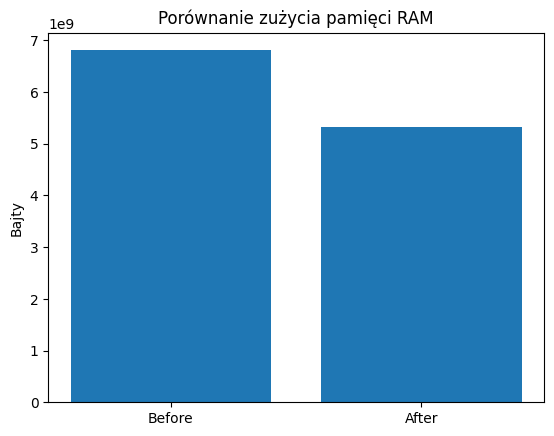

In [ ]:
plt.bar(['Before', 'After'], [before, after])
plt.title('Porównanie zużycia pamięci RAM')
plt.ylabel('Bajty')
plt.show()

# **Zadanie 3**

Wykonaj 3 wybrane operacje (grupowanie + agregacja, filtrowanie, itp.) na całej ramce i zmierz czas wykonania na danych oryginalnych i zoptymalizowanych. Wyświetl te czasy.

In [ ]:
def measure_time(func):
    start = datetime.now()
    result = func()
    print(f"Czas: {datetime.now() - start}")
    return result

**Grupowanie danych (groupby + średnia)**

In [ ]:
def test_groupby(df):
    return df.groupby('username')['likes'].mean()

In [ ]:
print("GROUPBY - oryginalne:")
measure_time(lambda: test_groupby(df))

print("GROUPBY - zoptymalizowane:")
measure_time(lambda: test_groupby(df_opt))

GROUPBY - oryginalne:
Czas: 0:00:02.011260
GROUPBY - zoptymalizowane:
Czas: 0:00:00.171436


/tmp/ipykernel_151/286280540.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby('username')['likes'].mean()


,likes
username,
0.000000009,8.500000
0.0_takemeaway,31.583333
0.1_natalie,60.222222
0.4.0i_v,123.250000
0.5jzgte,41.000000
...,...
zzzzlata_s,121.250000
zzzzzandy1,15.428571
zzzzzchon,50.812500


**Filtrowanie danych**

In [ ]:
def test_filter(df):
    return df[df['likes'] > 100]

In [ ]:
print("FILTER - oryginalne:")
measure_time(lambda: test_filter(df))

print("FILTER - zoptymalizowane:")
measure_time(lambda: test_filter(df_opt))

FILTER - oryginalne:
Czas: 0:00:00.623812
FILTER - zoptymalizowane:
Czas: 0:00:00.392588


,username,lang,category,date,sid,sid_profile,profile_id,post_type,likes,comments,following,followers,num_posts,is_business_account,post_id,description,bio
2,andylund_,en,science_&_technology,2019-03-05 08:03:11,28370905,3496776,2237947779,1,168,3,520,1204,494,False,Bunhd1DFVAG,Tech Tuesday. Been flat out on the tools. Got ...,"Professional Bicycle technician, Intense Racin..."
3,andylund_,en,diaries_&_daily_life,2018-11-01 20:17:41,28370907,3496776,2237947779,1,102,2,520,1204,494,False,Bppi85gliQK,"On the tools, my favourite wheel builds @stans...","Professional Bicycle technician, Intense Racin..."
4,andylund_,en,diaries_&_daily_life,2019-02-19 08:10:11,32170690,3496776,2237947779,1,145,2,520,1204,494,False,BuDfIyslzfw,Solid effort on the bar turn.\nFully turned.\n...,"Professional Bicycle technician, Intense Racin..."
5,andylund_,en,arts_&_culture,2019-05-07 08:33:51,14315358,3496776,2237947779,1,124,2,520,1204,494,False,BxJsMDpA2yH,Annual springtime flora picture.\nTurn bars in...,"Professional Bicycle technician, Intense Racin..."
6,andylund_,en,sports,2019-02-15 08:02:35,8304346,3496776,2237947779,1,150,3,520,1204,494,False,Bt5LFpZlm3z,Laps in spring like conditions. Getting these ...,"Professional Bicycle technician, Intense Racin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147349,chocolateinmyeyes,en,sports,2018-12-26 15:11:20,41258156,4223909,381626317,1,134,0,365,672,497,False,Br2nnV_HL3N,Never be a prisoner of your past. It was just ...,Si usted me conoce basado en lo que yo era un ...
1147350,chocolateinmyeyes,en,diaries_&_daily_life,2018-12-05 16:18:54,41258157,4223909,381626317,1,128,2,365,672,497,False,BrAqp2DHmdM,NO SEAS NORMAL 🚫,Si usted me conoce basado en lo que yo era un ...
1147352,chocolateinmyeyes,en,music,2018-11-11 19:09:56,41258159,4223909,381626317,1,121,0,365,672,497,False,BqDLJewnp7e,"""So hard to keep my own head""\n#beyoutiful #mo...",Si usted me conoce basado en lo que yo era un ...
1147353,chocolateinmyeyes,en,diaries_&_daily_life,2018-08-07 22:01:56,12584781,4223909,381626317,1,115,2,365,672,497,False,BmMLpyJlZ90,"Look deep into nuture, and then you will under...",Si usted me conoce basado en lo que yo era un ...


**Sortowanie danych**

In [ ]:
def test_sort(df):
    return df.sort_values(by='likes')

In [ ]:
print("SORT - oryginalne:")
measure_time(lambda: test_sort(df))

print("SORT - zoptymalizowane:")
measure_time(lambda: test_sort(df_opt))

SORT - oryginalne:
Czas: 0:00:09.062562
SORT - zoptymalizowane:
Czas: 0:00:05.754531


,username,lang,category,date,sid,sid_profile,profile_id,post_type,likes,comments,following,followers,num_posts,is_business_account,post_id,description,bio
965698,alexwxj8808,en,news_&_social_concern,2019-05-10 02:29:12,39153951,3864019,6530587275,1,0,0,23,39,108,False,BxQw1-aAAJA,No description,None
1077325,nicolerrabbit,en,diaries_&_daily_life,2019-04-29 12:18:44,30066568,4010009,7025243562,1,0,0,1618,0,14480,False,Bw1fkKghjuk,"Don't talk to me about sage or meditation, Fucko.","Oki, Napii! | Hello, Friend! NOT ACCEPTING FOL..."
1077324,nicolerrabbit,en,diaries_&_daily_life,2019-03-15 10:31:00,28176860,4010009,7025243562,1,0,0,1618,0,14480,False,BvBiVMfh_-s,Textbook Dawkins. 😞,"Oki, Napii! | Hello, Friend! NOT ACCEPTING FOL..."
814822,sylvie_rosanne_st_laurent,en,news_&_social_concern,2019-04-23 16:48:39,37395488,3618083,9391601043,1,0,0,33,18,68,False,Bwmhr6ulmZu,No description,None
162311,wanderinggryphon,en,news_&_social_concern,2019-04-13 19:54:05,9143179,3277103,4119492159,1,0,0,245,139,601,False,BwNG9PbnMts,No description,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727537,melton,en,diaries_&_daily_life,2019-06-30 00:34:25,40590874,303578,176350059,1,2226464,7722,458,6595133,565,False,BzT4P5vh5RM,you are the most beautiful human being i know....,@thesunisalsoastar
338691,lizakoshy,en,celebrity_&_pop_culture,2019-05-08 04:18:44,38331091,3747199,8443283,1,2329077,7609,1428,17920459,1782,True,BxLzya6FN6U,Pinky's up • To the brilliant beast of @balmai...,God 1st.\nLittle brown girl with big dreams.\n...
80511,akshaykumar,en,film_tv_&_video,2019-04-27 19:07:35,15396405,3513205,907025384,1,2331497,16905,5,26252169,1173,False,BwxEw9uHXIX,When #IronMan Wears the same Tie as you!!\n#Wh...,#AkshayKumar
338693,lizakoshy,en,diaries_&_daily_life,2019-04-14 21:47:13,38331101,3747199,8443283,1,2616479,10571,1428,17920459,1782,True,BwP4stXFS94,liza koshella,God 1st.\nLittle brown girl with big dreams.\n...


Wniosek:
Optymalizacja typów danych wpływa nie tylko na zużycie pamięci, ale również na wydajność obliczeń.

# **Zadanie 4**

Zapisz ramkę jako plik csv, z nagłówkami kolumn, bez indeksu. Sprawdź jaka jest różnica w wielkości pliku csv i sumy wielkości plików w formacie parquet (w eksploratorze, nie trzeba tego robić z poziomu kodu).

**Zapis CSV**

Zapisanie danych do pliku CSV

index=False = bez dodatkowej kolumny indeksu

In [ ]:
df.to_csv('instagram.csv', index=False)

CSV: ~2,07 GB

Parquet: ~864 MB

Plik CSV ma znacznie większy rozmiar niż pliki Parquet, ponieważ nie stosuje kompresji i przechowuje dane w formie tekstowej. Parquet przechowuje dane w formacie kolumnowym z kompresją, co znacząco zmniejsza rozmiar pliku.

# **Zadanie 5**

Zmierz czas wczytywania danych z pliku csv dla 3 przypadków:

cały plik na raz,
cały plik ze wskazaniem parametru chunksize (możesz poeksperymentować z wielkością tego parametru),
z użyciem multiprocessingu zaprezentowanego w przykładzie (wcześniej podziel plik na kilka mniejszych), wskazując ilość procesów jako ilość_rdzeni - 2 oraz drugi przypadek (ilosc_rdzeni - 2) * 2.

**Wczytanie całego pliku**

In [ ]:
start = datetime.now()
df_csv = pd.read_csv('instagram.csv')
print("CSV cały plik:", datetime.now() - start)

CSV cały plik: 0:01:06.780116


**Chunksize**

- plik dzielony na kawałki
- mniejsze zużycie RAM
- czas często podobny lub większy

In [ ]:
def read_chunks():
    chunks = pd.read_csv('instagram.csv', chunksize=500000)
    return pd.concat(chunks)

start = datetime.now()
df_chunks = read_chunks()
print("CSV chunks:", datetime.now() - start)

CSV chunks: 0:01:02.879451


**Multiprocessing**

In [ ]:
print("CPU:", os.cpu_count())

CPU: 2


CPU = 2

2 - 2 = 0

max(1, 0) = 1


Liczba procesów w multiprocessing musi być dodatnia. W środowisku Google Colab liczba dostępnych rdzeni CPU może być niska, dlatego należy stosować zabezpieczenie max(1, os.cpu_count() - 2).

In [ ]:
n_processes = max(1, os.cpu_count() - 2)
print("Processes:", n_processes)

Processes: 1


In [ ]:
def calc_likes(file):
    df = pd.read_parquet(file)
    return df['likes'].sum()

In [ ]:
start = datetime.now()

with Pool(processes=n_processes) as pool:
    results = pool.map(calc_likes, files)

total = sum(results)

print("SUMA likes:", total)
print("CZAS:", datetime.now() - start)

SUMA likes: 2455730335
CZAS: 0:00:33.442982


Najszybsze wczytanie zależy od rozmiaru danych i zasobów systemowych. Wczytywanie chunkami zmniejsza użycie pamięci, ale nie zawsze skraca czas. Multiprocessing pozwala równolegle przetwarzać pliki, jednak jego efektywność zależy od liczby rdzeni i narzutu komunikacji między procesami.

# **Zadanie 6**

(z gwiazdką, nie jest obowiązkowe, ale pouczające)

Wczytaj każdy plik podzielony w zadaniu 5 do oddzielnej ramki danych. Dla każdej ramki policz sumę na kolumnie likes, a następnie policz sumę tych sum. Tę część zadania wykonaj sekwencyjnie. Teraz wykorzystując multiprocessing (i przykłady z labu) wykonaj to samo zadanie zrównoleglając je. Zmierz czas obu przypadków i go wyświetl.

**Podejście sekwencyjne**

W podejściu sekwencyjnym każdy plik jest przetwarzany jeden po drugim. Dla każdego pliku obliczana jest suma kolumny `likes`, a następnie wyniki są sumowane.

In [ ]:
start = datetime.now()

total_seq = 0

for f in files:
    df = pd.read_parquet(f)
    total_seq += df['likes'].sum()

print("SEKWENCYJNIE SUMA:", total_seq)
print("CZAS:", datetime.now() - start)

SEKWENCYJNIE SUMA: 2455730335
CZAS: 0:00:32.281752


**Podejście równoległe (multiprocessing)**

In [ ]:
def calc_likes(file):
    df = pd.read_parquet(file)
    return df['likes'].sum()

Liczba procesów

In [ ]:
n_processes = max(1, os.cpu_count() - 2)
print("Processes:", n_processes)

Processes: 1


In [ ]:
start = datetime.now()

with Pool(processes=n_processes) as pool:
    results = pool.map(calc_likes, files)

total_mp = sum(results)

print("MULTIPROCESSING SUMA:", total_mp)
print("CZAS:", datetime.now() - start)

MULTIPROCESSING SUMA: 2455730335
CZAS: 0:00:26.612580


W podejściu sekwencyjnym każdy plik jest przetwarzany jeden po drugim, co wydłuża czas wykonania.

W podejściu równoległym (multiprocessing) każdy proces oblicza sumę niezależnie dla osobnego pliku, co pozwala skrócić czas dzięki wykorzystaniu wielu rdzeni CPU.